In [22]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

try:
    import matplotlib.pyplot as plt
except ImportError:
    plt = None

try:
    from tqdm import tqdm
except ImportError:
    class _SimpleTQDM:
        def __init__(self, iterable, desc=None):
            self.iterable = iterable
            self.desc = desc

        def __iter__(self):
            return iter(self.iterable)

        def set_postfix(self, *args, **kwargs):
            pass

    def tqdm(iterable, desc=None):
        return _SimpleTQDM(iterable, desc=desc)


In [23]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])
train_dataset = datasets.MNIST(root='Gans/data', train=True, download=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)


In [24]:
class Critic(nn.Module):
    def __init__(self):
        super().__init__()

        self.model = nn.Sequential(
            nn.Linear(784, 1024),
            nn.LeakyReLU(0.2),

            nn.Linear(1024, 512),
            nn.LeakyReLU(0.2),

            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),

            nn.Linear(256, 128),
            nn.LeakyReLU(0.2),

            nn.Linear(128, 1)
        )

    def forward(self, x):
        x = x.view(x.size(0), -1)
        return self.model(x)


Step 1 uses a WGAN-style critic, so the last layer stays linear and we do not add `nn.Sigmoid()` or `BCELoss`.


In [25]:
class Generator(nn.Module):
    def __init__(self, noise_dim=100):
        super().__init__()

        self.model = nn.Sequential(
            nn.Linear(noise_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),

            nn.Linear(256, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),

            nn.Linear(512, 1024),
            nn.BatchNorm1d(1024),
            nn.ReLU(),

            nn.Linear(1024, 1024),
            nn.BatchNorm1d(1024),
            nn.ReLU(),

            nn.Linear(1024, 784),
            nn.Tanh()
        )

    def forward(self, x):
        return self.model(x)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
noise_dim = 100

C = Critic().to(device)
G = Generator(noise_dim).to(device)

c_optimizer = optim.Adam(C.parameters(), lr=0.0001, betas=(0.0, 0.9))
g_optimizer = optim.Adam(G.parameters(), lr=0.0001, betas=(0.0, 0.9))

lambda_gp = 10
fixed_noise = torch.randn(16, noise_dim, device=device)
fixed_noise_samples = []


def gradient_penalty(critic, real_images, fake_images):
    batch_size = real_images.size(0)
    epsilon = torch.rand(batch_size, 1, device=real_images.device)
    epsilon = epsilon.expand_as(real_images)

    interpolated = epsilon * real_images + (1 - epsilon) * fake_images
    interpolated.requires_grad_(True)

    interpolated_score = critic(interpolated)

    gradients = torch.autograd.grad(
        outputs=interpolated_score,
        inputs=interpolated,
        grad_outputs=torch.ones_like(interpolated_score),
        create_graph=True,
        retain_graph=True,
        only_inputs=True
    )[0]

    gradients = gradients.view(batch_size, -1)
    gradient_norm = gradients.norm(2, dim=1)
    return ((gradient_norm - 1) ** 2).mean()


In [26]:
num_epochs = 50
n_critic = 5

for epoch in range(num_epochs):
    progress_bar = tqdm(train_loader, desc=f"Epoch {epoch + 1}/{num_epochs}")

    for real_images, _ in progress_bar:
        real_images = real_images.view(real_images.size(0), -1).to(device)
        batch_size = real_images.size(0)

        for _ in range(n_critic):
            noise = torch.randn(batch_size, noise_dim, device=device)
            fake_images = G(noise)

            real_score = C(real_images)
            fake_score = C(fake_images.detach())

            gp = gradient_penalty(C, real_images, fake_images.detach())
            critic_loss = fake_score.mean() - real_score.mean() + lambda_gp * gp

            c_optimizer.zero_grad()
            critic_loss.backward()
            c_optimizer.step()

        noise = torch.randn(batch_size, noise_dim, device=device)
        fake_images = G(noise)

        fake_score = C(fake_images)
        g_loss = -fake_score.mean()

        g_optimizer.zero_grad()
        g_loss.backward()
        g_optimizer.step()

        progress_bar.set_postfix({
            "C_loss": f"{critic_loss.item():.4f}",
            "G_loss": f"{g_loss.item():.4f}",
            "GP": f"{gp.item():.4f}"
        })

    with torch.no_grad():
        fixed_noise_samples.append(G(fixed_noise).detach().cpu())


Epoch 11/50:  99%|█████████▉| 933/938 [00:46<00:00, 19.91it/s, C_loss=-1.9034, G_loss=-1.9977, GP=0.0213]


KeyboardInterrupt: 

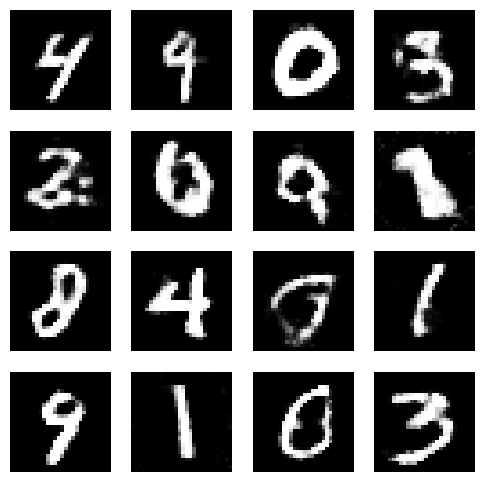

In [27]:
if plt is None:
    print("matplotlib is not installed, so generated-image plotting is skipped.")
else:
    G.eval()

    with torch.no_grad():
        fake_images = G(fixed_noise).cpu()

    fake_images = fake_images.view(-1, 28, 28)
    fake_images = (fake_images + 1) / 2

    plt.figure(figsize=(6, 6))

    for i in range(16):
        plt.subplot(4, 4, i + 1)
        plt.imshow(fake_images[i], cmap="gray")
        plt.axis("off")

    plt.show()
    G.train()


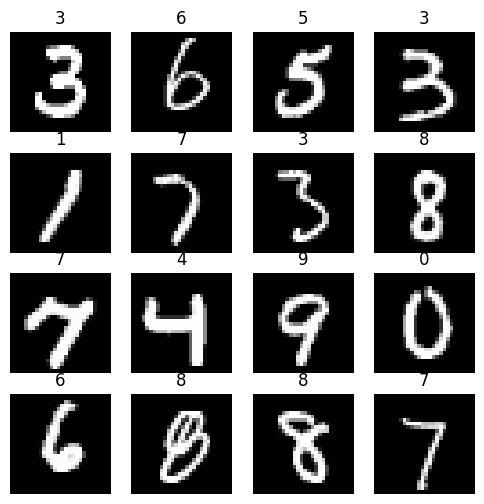

In [28]:
if plt is None:
    print("matplotlib is not installed, so real-image plotting is skipped.")
else:
    real_images, real_labels = next(iter(train_loader))
    real_images = real_images[:16]
    real_images = (real_images + 1) / 2

    plt.figure(figsize=(6, 6))

    for i in range(16):
        plt.subplot(4, 4, i + 1)
        plt.imshow(real_images[i].squeeze(), cmap="gray")
        plt.title(str(real_labels[i].item()))
        plt.axis("off")

    plt.show()
